# 🦠 COVID-19 Global EDA Dashboard
**Author:** Muhammad Hanzla  
**Dataset:** COVID-19 Clean Complete Dataset (Kaggle)  
**Stack:** Python · Pandas · Matplotlib · Seaborn · Plotly · Prophet  
**Goal:** 50+ visualizations — global trends, country comparisons, heatmaps & forecasting.

---
## Pipeline
`Load Data` → `Cleaning` → `Global EDA` → `Country Analysis` → `Time-Series` → `Heatmaps` → `Plotly Interactive` → `Prophet Forecast`

> 📌 **Dataset:** https://www.kaggle.com/datasets/imdevskp/corona-virus-report

<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 35px; border-radius: 12px; text-align: center; border: 1px solid #1e40af;">

<h2 style="color: #60a5fa; margin-bottom: 5px;">👨‍💻 About the Author</h2>
<h3 style="color: #f1f5f9; margin-top: 0;">Muhammad Hanzla</h3>

<p style="color: #94a3b8; font-size: 15px; max-width: 600px; margin: 0 auto 20px auto;">A passionate <strong style="color: #38bdf8;">Data Scientist</strong> with a keen interest in machine learning, data analysis, and building intelligent solutions. Always exploring new datasets, uncovering hidden patterns, and turning raw data into meaningful insights.</p>

<hr style="border: none; border-top: 1px solid #1e40af; margin: 20px auto; width: 60%;">

<p style="color: #64748b; font-size: 13px; margin-bottom: 15px; letter-spacing: 1px; text-transform: uppercase;">🔗 Connect &amp; Collaborate</p>

<p style="text-align: center;"><a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>📧 Email</a> <a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>📊 Kaggle</a> <a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>💻 GitHub</a> <a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>💼 LinkedIn</a> <a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>📷 Instagram</a></p>

<p style="color: #475569; font-size: 12px; margin-top: 25px;">💡 <em>"Data is the new oil — and I love refining it."</em></p>

</div>

## 1. Install & Import Libraries

In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','prophet','plotly','-q'], check=False)
print('✅ Packages ready')

✅ Packages ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe' 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)
np.random.seed(42)
print('✅ All libraries loaded')

✅ All libraries loaded


## 2. Load Dataset
Using the **COVID-19 Clean Complete** dataset — daily cases/deaths/recovered for every country from Jan 2020 onwards.

In [3]:
PATH = '/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv'

df = pd.read_csv(PATH)
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print(f'\nDate range: {df["Date"].min()}  →  {df["Date"].max()}')
print(f'Countries : {df["Country/Region"].nunique()}')
df.head(5)

Shape   : (49068, 10)
Columns : ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

Date range: 2020-01-22  →  2020-07-27
Countries : 187


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.94,67.71,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15,20.17,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03,1.66,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.51,1.52,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20,17.87,2020-01-22,0,0,0,0,Africa


## 3. Data Cleaning & Preparation

In [4]:
# Parse dates
df['Date'] = pd.to_datetime(df['Date'])

# Rename columns for convenience
df.rename(columns={
    'Country/Region' : 'Country',
    'Province/State' : 'Province',
}, inplace=True)

# Fill missing values
df['Province']  = df['Province'].fillna('')
df['Confirmed'] = df['Confirmed'].fillna(0)
df['Deaths']    = df['Deaths'].fillna(0)
df['Recovered'] = df['Recovered'].fillna(0)
df['Active']    = df.get('Active', df['Confirmed'] - df['Deaths'] - df['Recovered'])
df['Active']    = df['Active'].clip(lower=0)

# Derived metrics
df['Death_Rate']     = np.where(df['Confirmed']>0, df['Deaths']/df['Confirmed']*100, 0)
df['Recovery_Rate']  = np.where(df['Confirmed']>0, df['Recovered']/df['Confirmed']*100, 0)

# Aggregate by Country + Date (remove province duplicates)
country_day = (df.groupby(['Country','Date'])
                 .agg(Confirmed=('Confirmed','sum'),
                      Deaths=('Deaths','sum'),
                      Recovered=('Recovered','sum'),
                      Active=('Active','sum'))
                 .reset_index())
country_day['Death_Rate']    = np.where(country_day['Confirmed']>0,
    country_day['Deaths']/country_day['Confirmed']*100, 0)
country_day['Recovery_Rate'] = np.where(country_day['Confirmed']>0,
    country_day['Recovered']/country_day['Confirmed']*100, 0)

# Latest snapshot
latest = country_day[country_day['Date']==country_day['Date'].max()].copy()
latest.sort_values('Confirmed', ascending=False, inplace=True)

print(f'Cleaned shape  : {country_day.shape}')
print(f'Latest date    : {country_day["Date"].max().date()}')
print(f'Total confirmed: {latest["Confirmed"].sum():,.0f}')
print(f'Total deaths   : {latest["Deaths"].sum():,.0f}')
print(f'Total recovered: {latest["Recovered"].sum():,.0f}')
latest.head(10)

Cleaned shape  : (35156, 8)
Latest date    : 2020-07-27
Total confirmed: 16,480,485
Total deaths   : 654,036
Total recovered: 9,468,087


,Country,Date,Confirmed,Deaths,Recovered,Active,Death_Rate,Recovery_Rate
32711,US,2020-07-27,4290259,148011,1325804,2816444,3.45,30.90
4511,Brazil,2020-07-27,2442375,87618,1846641,508116,3.59,75.61
15039,India,2020-07-27,1480073,33408,951166,495499,2.26,64.26
26131,Russia,2020-07-27,816680,13334,602249,201097,1.63,73.74
29139,South Africa,2020-07-27,452529,7067,274925,170537,1.56,60.75
21055,Mexico,2020-07-27,395489,44022,303810,47657,11.13,76.82
25003,Peru,2020-07-27,389717,18418,272547,98752,4.73,69.93
6767,Chile,2020-07-27,347923,9187,319954,18782,2.64,91.96
33463,United Kingdom,2020-07-27,301708,45844,1437,254427,15.19,0.48
15415,Iran,2020-07-27,293606,15912,255144,22550,5.42,86.90


## 4. Global Overview — Summary Stats

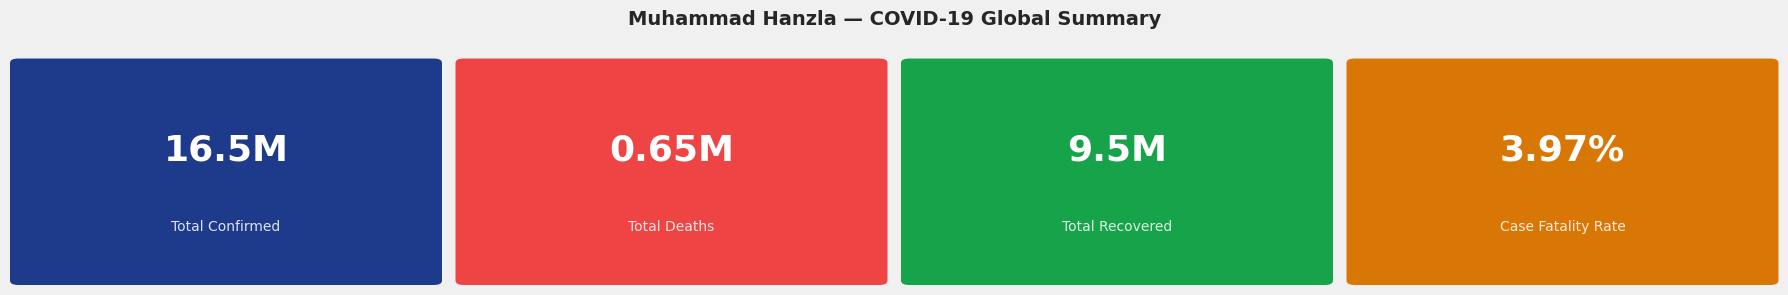

Summary cards saved ✅


In [5]:
from matplotlib.patches import FancyBboxPatch

# Global daily totals
global_day = (country_day.groupby('Date')
               .agg(Confirmed=('Confirmed','sum'),
                    Deaths=('Deaths','sum'),
                    Recovered=('Recovered','sum'),
                    Active=('Active','sum'))
               .reset_index())

# Daily new cases (difference)
global_day['New_Cases']    = global_day['Confirmed'].diff().clip(lower=0)
global_day['New_Deaths']   = global_day['Deaths'].diff().clip(lower=0)
global_day['7d_avg_cases'] = global_day['New_Cases'].rolling(7).mean()
global_day['7d_avg_deaths']= global_day['New_Deaths'].rolling(7).mean()

# Summary cards
total_confirmed = global_day['Confirmed'].iloc[-1]
total_deaths    = global_day['Deaths'].iloc[-1]
total_recovered = global_day['Recovered'].iloc[-1]
global_cfr      = total_deaths / total_confirmed * 100

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
fig.patch.set_facecolor('#f0f0f0')
fig.suptitle('Muhammad Hanzla — COVID-19 Global Summary', fontsize=14, fontweight='bold')

cards = [
    ('Total Confirmed',    f'{total_confirmed/1e6:.1f}M', '#1e3a8a'),
    ('Total Deaths',       f'{total_deaths/1e6:.2f}M',   '#ef4444'),
    ('Total Recovered',    f'{total_recovered/1e6:.1f}M', '#16a34a'),
    ('Case Fatality Rate', f'{global_cfr:.2f}%',          '#d97706'),
]

for ax, (label, value, color) in zip(axes, cards):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Draw colored background rectangle manually
    rect = FancyBboxPatch((0, 0), 1, 1,
                           boxstyle="round,pad=0.02",
                           facecolor=color, edgecolor='none',
                           transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)

    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=26, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=10, color=(1, 1, 1, 0.85),
            transform=ax.transAxes)

plt.tight_layout()
plt.savefig('01_summary_cards.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary cards saved ✅')

## 5. Global Trend Analysis

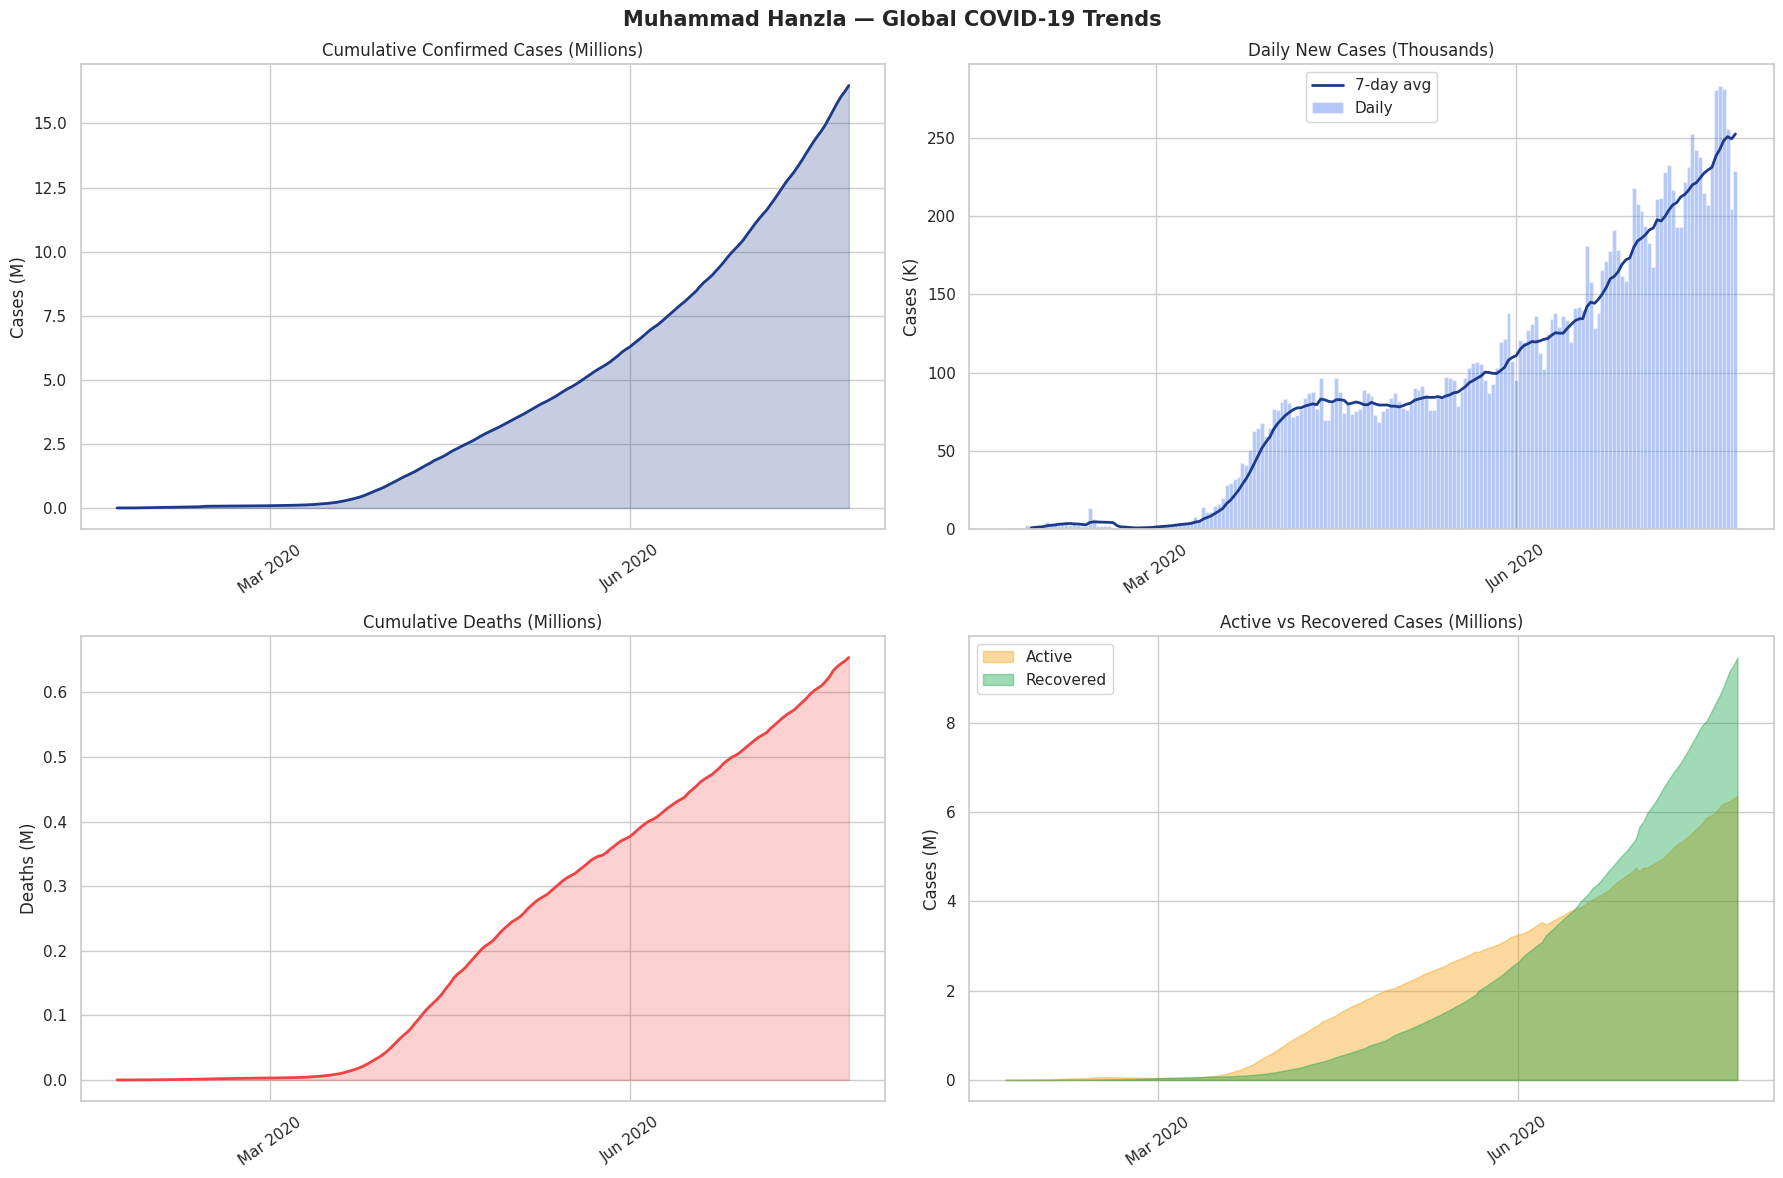

Global trends saved ✅


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Muhammad Hanzla — Global COVID-19 Trends', fontsize=15, fontweight='bold')

# Cumulative cases
axes[0,0].fill_between(global_day['Date'], global_day['Confirmed']/1e6,
                         alpha=0.25, color='#1e3a8a')
axes[0,0].plot(global_day['Date'], global_day['Confirmed']/1e6,
                color='#1e3a8a', lw=2)
axes[0,0].set_title('Cumulative Confirmed Cases (Millions)')
axes[0,0].set_ylabel('Cases (M)'); axes[0,0].set_xlabel('')
axes[0,0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,0].tick_params(axis='x', rotation=35)

# Daily new cases + 7d avg
axes[0,1].bar(global_day['Date'], global_day['New_Cases']/1e3,
               alpha=0.35, color='#2563eb', width=1, label='Daily')
axes[0,1].plot(global_day['Date'], global_day['7d_avg_cases']/1e3,
                color='#1e3a8a', lw=2, label='7-day avg')
axes[0,1].set_title('Daily New Cases (Thousands)')
axes[0,1].set_ylabel('Cases (K)'); axes[0,1].legend()
axes[0,1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,1].tick_params(axis='x', rotation=35)

# Cumulative deaths
axes[1,0].fill_between(global_day['Date'], global_day['Deaths']/1e6,
                         alpha=0.25, color='#ef4444')
axes[1,0].plot(global_day['Date'], global_day['Deaths']/1e6,
                color='#ef4444', lw=2)
axes[1,0].set_title('Cumulative Deaths (Millions)')
axes[1,0].set_ylabel('Deaths (M)')
axes[1,0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1,0].tick_params(axis='x', rotation=35)

# Active vs Recovered
axes[1,1].fill_between(global_day['Date'], global_day['Active']/1e6,
                         alpha=0.4, color='#f59e0b', label='Active')
axes[1,1].fill_between(global_day['Date'], global_day['Recovered']/1e6,
                         alpha=0.4, color='#16a34a', label='Recovered')
axes[1,1].set_title('Active vs Recovered Cases (Millions)')
axes[1,1].set_ylabel('Cases (M)'); axes[1,1].legend()
axes[1,1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1,1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('02_global_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Global trends saved ✅')

## 6. Top 15 Countries Analysis

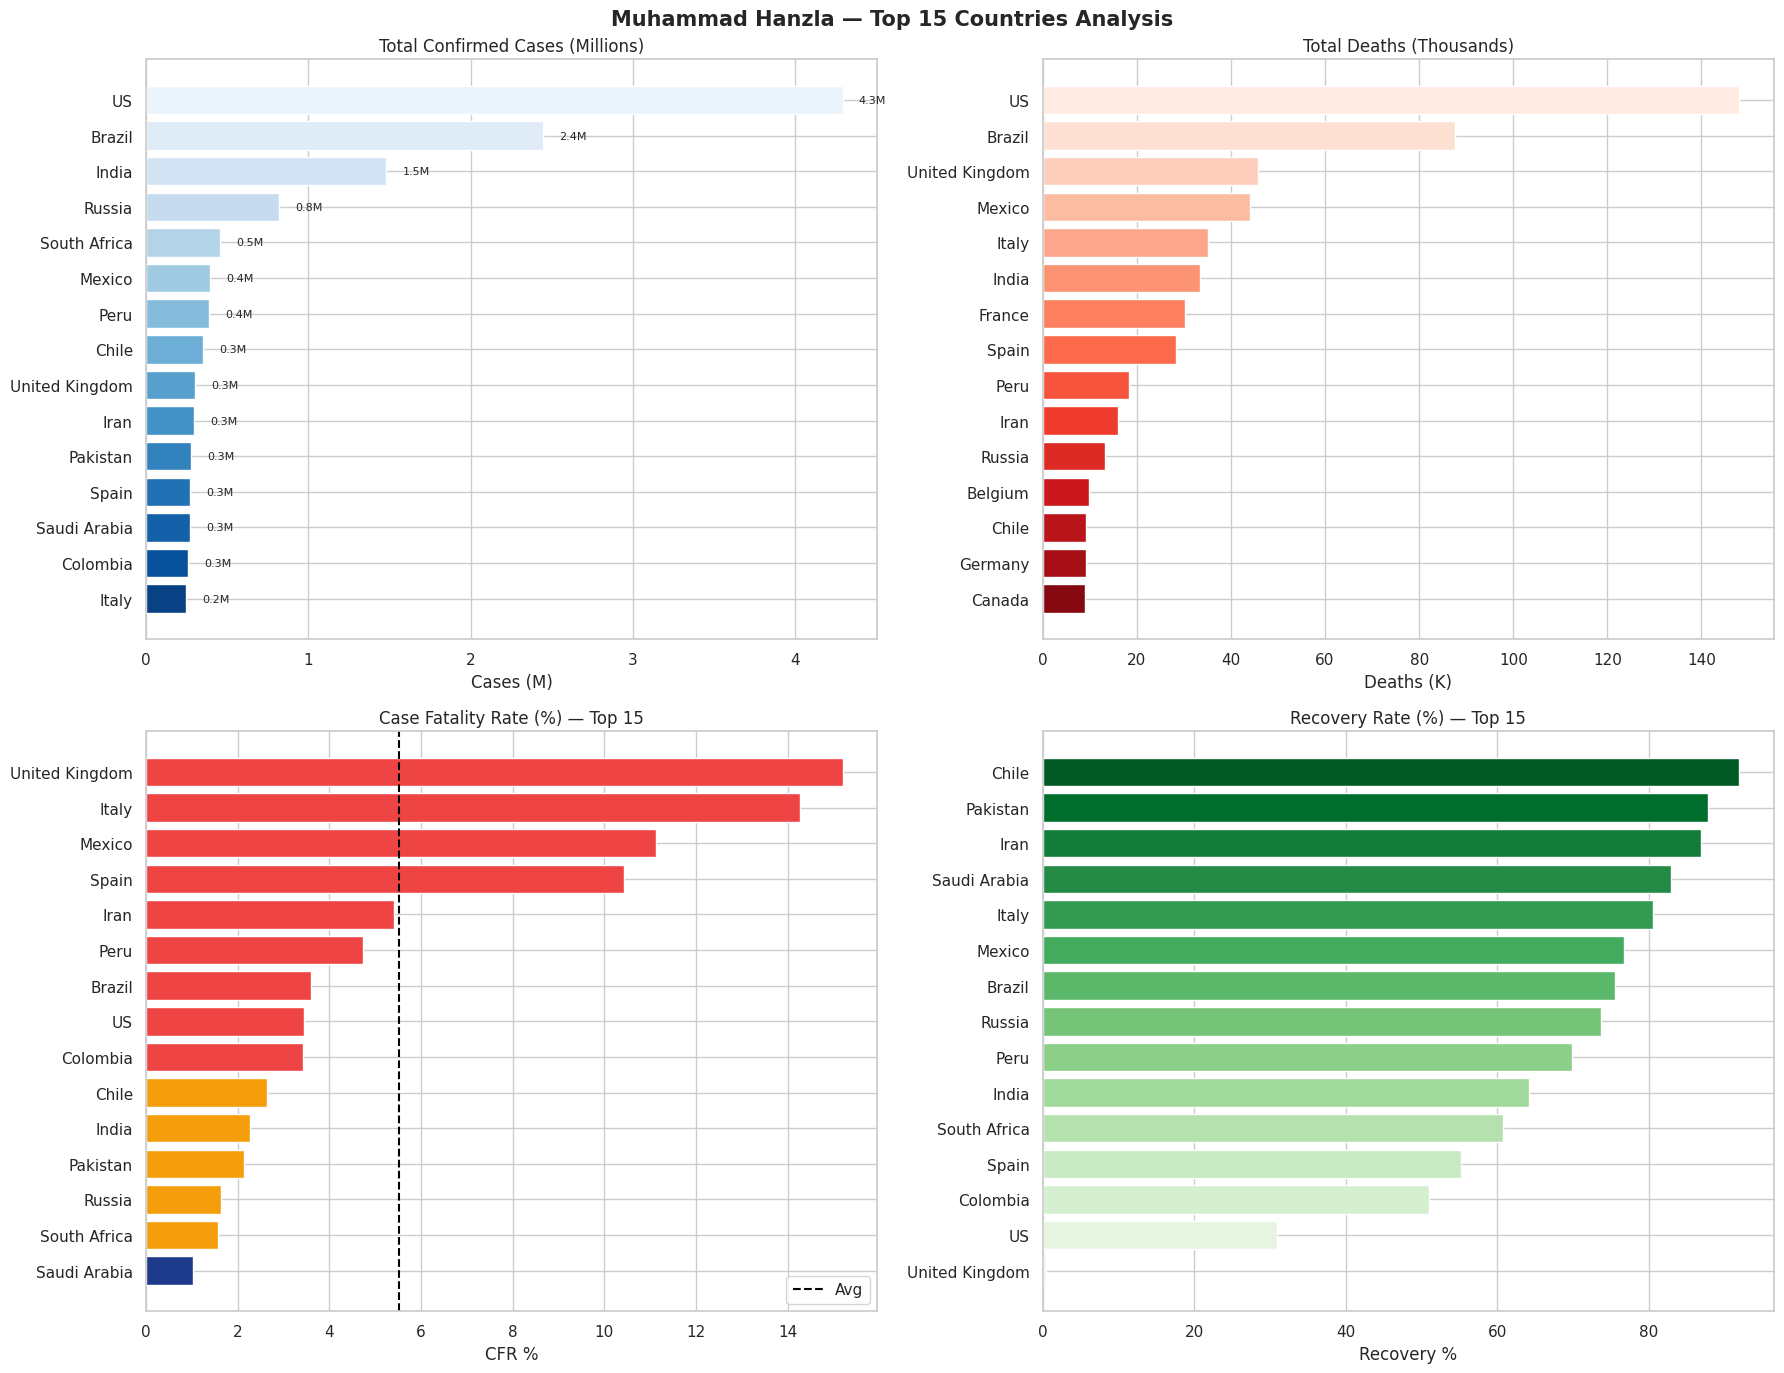

Top countries saved ✅


In [7]:
top15 = latest.head(15).copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Muhammad Hanzla — Top 15 Countries Analysis', fontsize=15, fontweight='bold')

palette_15 = sns.color_palette('Blues_r', 15)

# Confirmed cases
bars = axes[0,0].barh(top15['Country'][::-1], top15['Confirmed'][::-1]/1e6,
                        color=palette_15, edgecolor='white')
axes[0,0].set_title('Total Confirmed Cases (Millions)')
axes[0,0].set_xlabel('Cases (M)')
for bar, val in zip(bars, top15['Confirmed'][::-1]/1e6):
    axes[0,0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                    f'{val:.1f}M', va='center', fontsize=8)

# Total deaths
top15_deaths = latest.nlargest(15,'Deaths')
axes[0,1].barh(top15_deaths['Country'][::-1], top15_deaths['Deaths'][::-1]/1e3,
                color=sns.color_palette('Reds_r',15), edgecolor='white')
axes[0,1].set_title('Total Deaths (Thousands)')
axes[0,1].set_xlabel('Deaths (K)')

# Death rate (top 15 by confirmed only)
top15_cfr = top15.sort_values('Death_Rate', ascending=True)
colors_cfr = ['#ef4444' if v>3 else '#f59e0b' if v>1.5 else '#1e3a8a'
               for v in top15_cfr['Death_Rate']]
axes[1,0].barh(top15_cfr['Country'], top15_cfr['Death_Rate'],
                color=colors_cfr, edgecolor='white')
axes[1,0].axvline(top15_cfr['Death_Rate'].mean(), color='black',
                   ls='--', lw=1.5, label='Avg')
axes[1,0].set_title('Case Fatality Rate (%) — Top 15')
axes[1,0].set_xlabel('CFR %'); axes[1,0].legend()

# Recovery rate
top15_rec = top15.sort_values('Recovery_Rate', ascending=True)
axes[1,1].barh(top15_rec['Country'], top15_rec['Recovery_Rate'],
                color=sns.color_palette('Greens_r',15)[::-1], edgecolor='white')
axes[1,1].set_title('Recovery Rate (%) — Top 15')
axes[1,1].set_xlabel('Recovery %')

plt.tight_layout()
plt.savefig('03_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top countries saved ✅')

## 7. Country Comparison — Time-Series

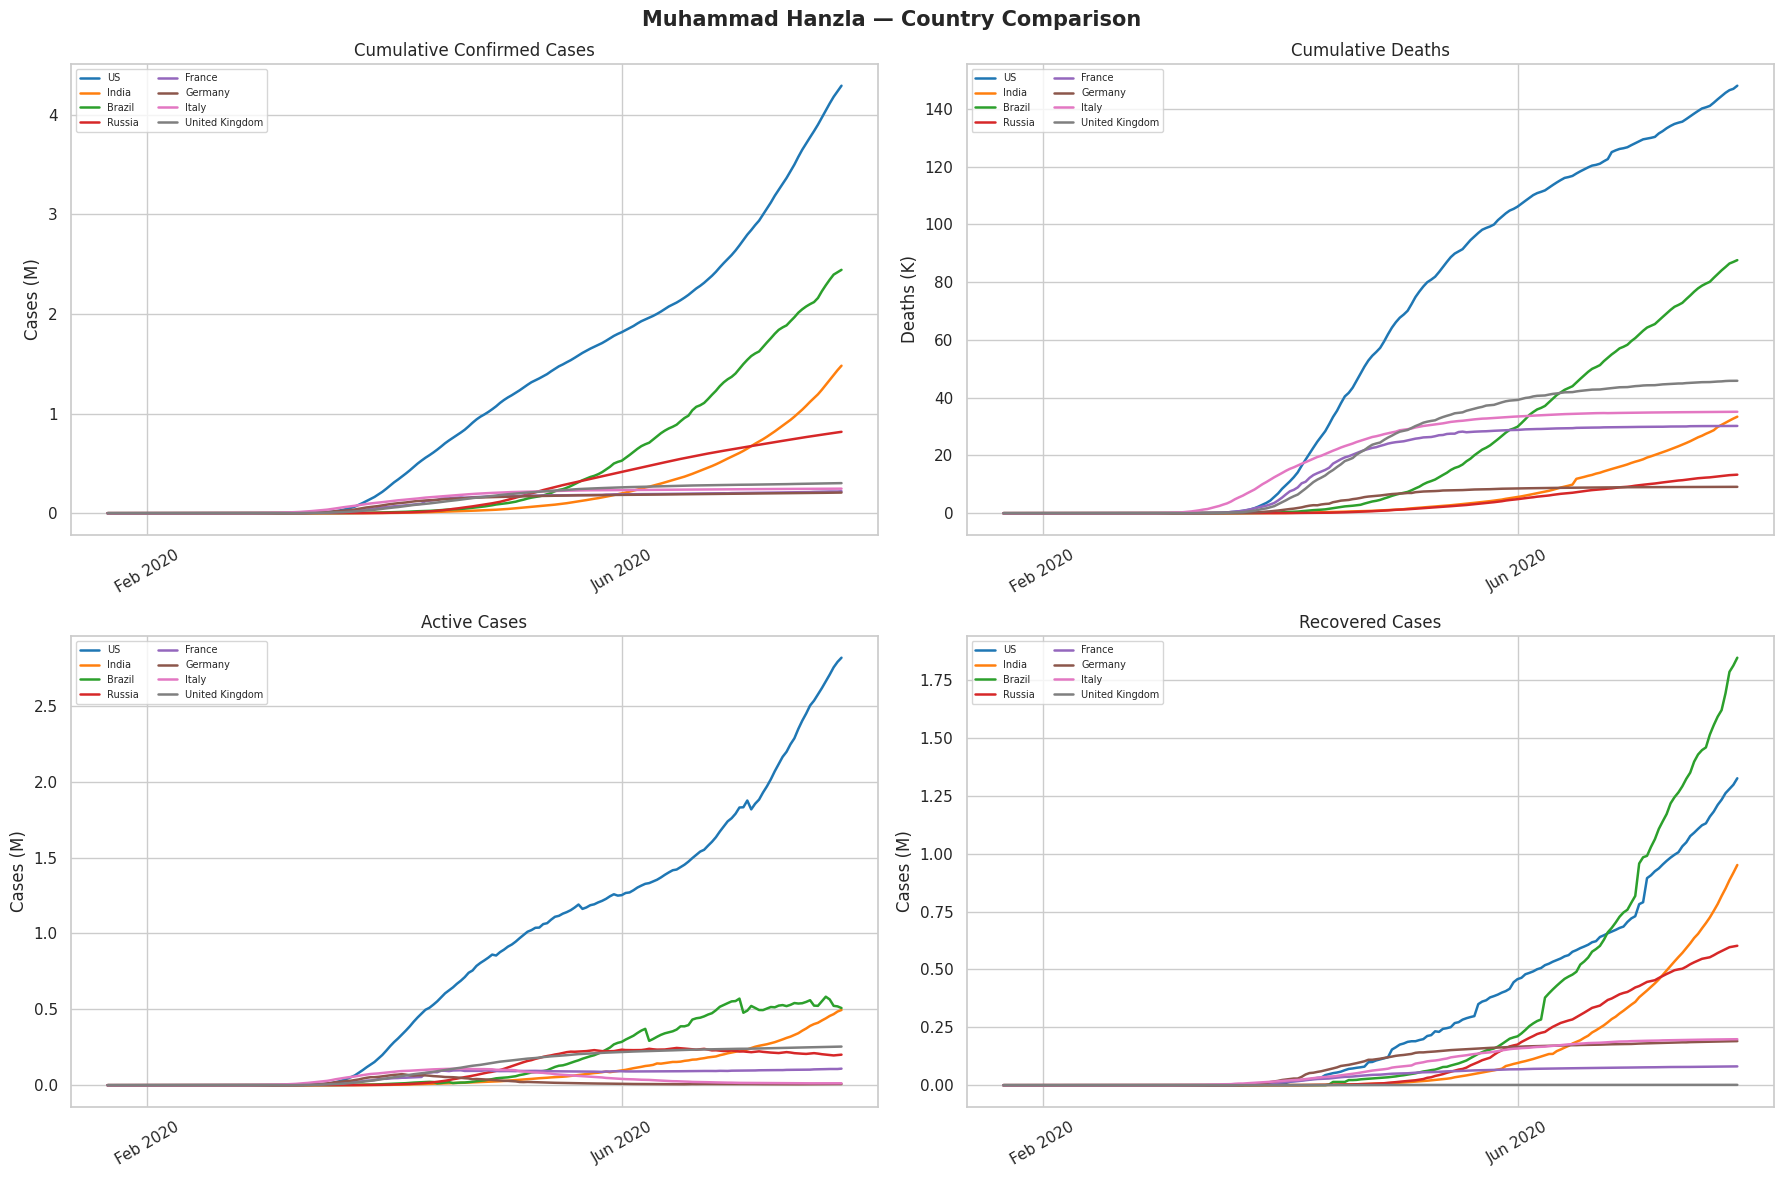

Country comparison saved ✅


In [8]:
COUNTRIES = ['US','India','Brazil','Russia','France','Germany','Italy','United Kingdom']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Muhammad Hanzla — Country Comparison', fontsize=15, fontweight='bold')

palette_c = sns.color_palette('tab10', len(COUNTRIES))

for col, (ax, metric, ylabel, title) in enumerate([
    (axes[0,0], 'Confirmed', 'Cases (M)',   'Cumulative Confirmed Cases'),
    (axes[0,1], 'Deaths',   'Deaths (K)',  'Cumulative Deaths'),
    (axes[1,0], 'Active',   'Cases (M)',   'Active Cases'),
    (axes[1,1], 'Recovered','Cases (M)',   'Recovered Cases'),
]):
    divisor = 1e3 if metric=='Deaths' else 1e6
    for i, ctry in enumerate(COUNTRIES):
        sub = country_day[country_day['Country']==ctry]
        if len(sub):
            ax.plot(sub['Date'], sub[metric]/divisor,
                     lw=1.8, label=ctry, color=palette_c[i])
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('04_country_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Country comparison saved ✅')

## 8. Heatmaps — Monthly & Country

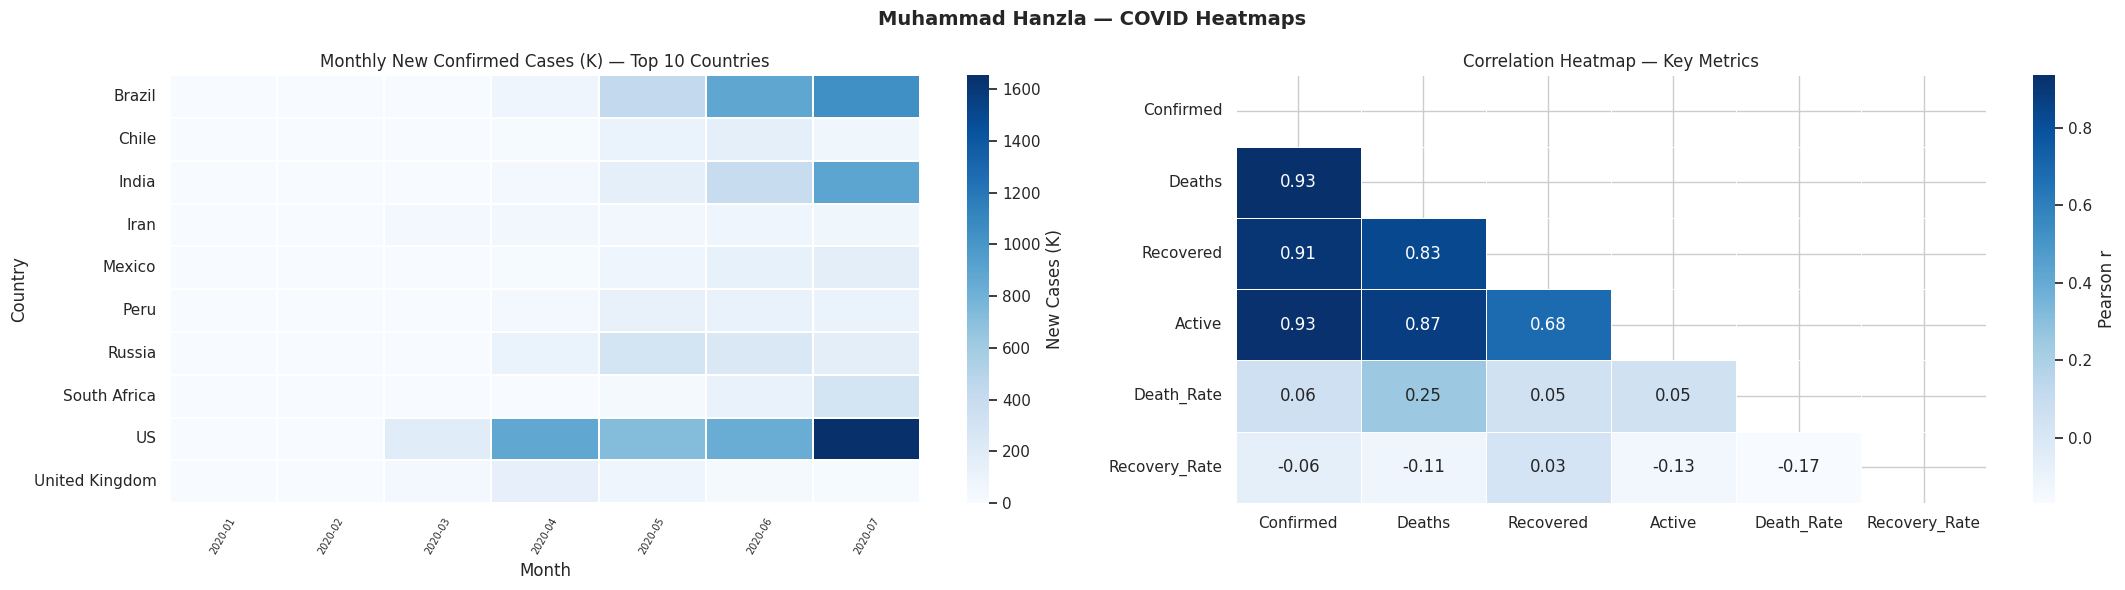

Heatmaps saved ✅


In [9]:
# Monthly new cases heatmap — Top 10 countries
top10_countries = latest.head(10)['Country'].tolist()
heat_df         = country_day[country_day['Country'].isin(top10_countries)].copy()
heat_df['Month']= heat_df['Date'].dt.to_period('M').astype(str)

# Monthly confirmed (latest value per month per country)
monthly = (heat_df.groupby(['Country','Month'])['Confirmed']
             .last().unstack(fill_value=0))
monthly_new = monthly.diff(axis=1).fillna(0).clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.suptitle('Muhammad Hanzla — COVID Heatmaps', fontsize=14, fontweight='bold')

# Heatmap 1: Monthly new cases
sns.heatmap(monthly_new/1e3, ax=axes[0], cmap='Blues',
             annot=False, linewidths=0.3, linecolor='white',
             cbar_kws={'label':'New Cases (K)'})
axes[0].set_title('Monthly New Confirmed Cases (K) — Top 10 Countries')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Country')
axes[0].tick_params(axis='x', rotation=60, labelsize=7)

# Heatmap 2: Correlation between key metrics
corr_df = latest[['Confirmed','Deaths','Recovered','Active','Death_Rate','Recovery_Rate']]
corr    = corr_df.corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1], annot=True, fmt='.2f', cmap='Blues',
             mask=mask, linewidths=0.5,
             cbar_kws={'label':'Pearson r'})
axes[1].set_title('Correlation Heatmap — Key Metrics')

plt.tight_layout()
plt.savefig('05_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmaps saved ✅')

## 9. Wave Analysis — Identifying Pandemic Waves

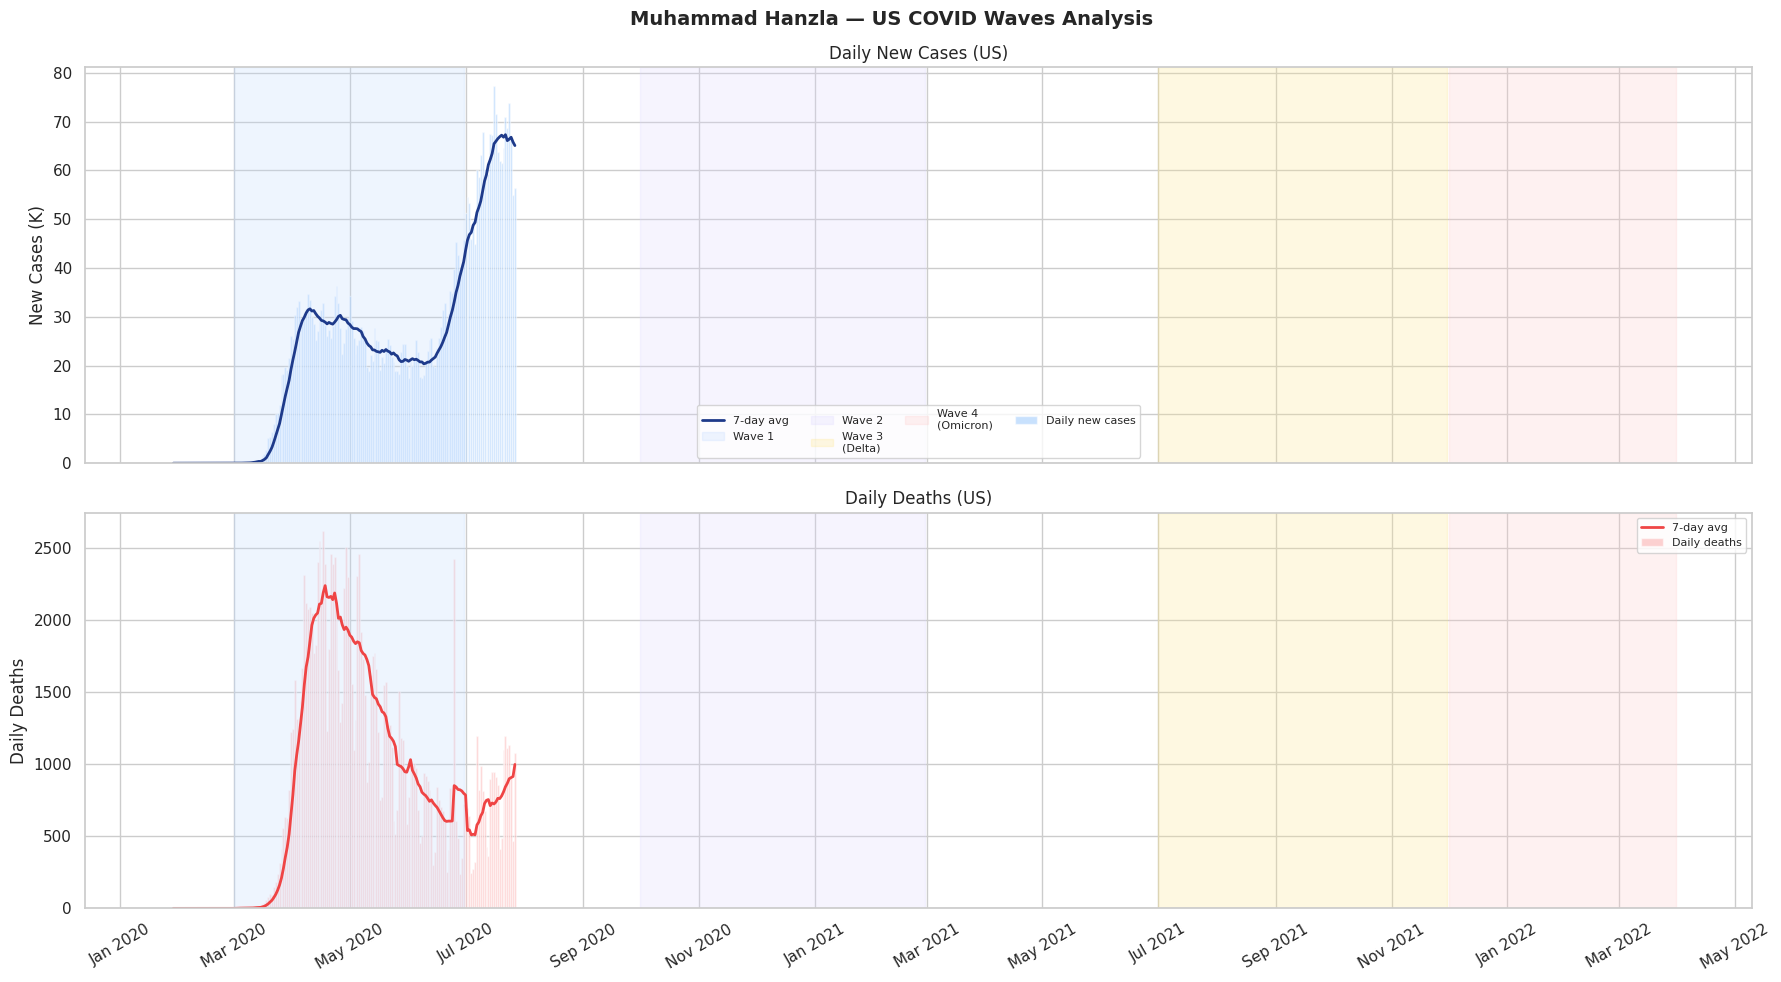

Wave analysis saved ✅


In [10]:
# Focus on US as case study for wave detection
us = country_day[country_day['Country']=='US'].copy()
us['New_Cases']    = us['Confirmed'].diff().clip(lower=0)
us['7d_avg']       = us['New_Cases'].rolling(7).mean()
us['New_Deaths']   = us['Deaths'].diff().clip(lower=0)
us['7d_avg_deaths']= us['New_Deaths'].rolling(7).mean()

# Annotate waves
waves = [
    ('Wave 1', '2020-03-01', '2020-06-30', '#bfdbfe'),
    ('Wave 2', '2020-10-01', '2021-02-28', '#ddd6fe'),
    ('Wave 3\n(Delta)',  '2021-07-01', '2021-11-30', '#fde68a'),
    ('Wave 4\n(Omicron)','2021-12-01', '2022-03-31', '#fecaca'),
]

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Muhammad Hanzla — US COVID Waves Analysis', fontsize=14, fontweight='bold')

# New cases
axes[0].bar(us['Date'], us['New_Cases']/1e3, color='#93c5fd', alpha=0.5,
             width=1, label='Daily new cases')
axes[0].plot(us['Date'], us['7d_avg']/1e3, color='#1e3a8a',
              lw=2, label='7-day avg')
for wave, start, end, color in waves:
    axes[0].axvspan(pd.to_datetime(start), pd.to_datetime(end),
                     alpha=0.25, color=color, label=wave)
axes[0].set_ylabel('New Cases (K)'); axes[0].legend(fontsize=8, ncol=4)
axes[0].set_title('Daily New Cases (US)')

# New deaths
axes[1].bar(us['Date'], us['New_Deaths'], color='#fca5a5', alpha=0.5,
             width=1, label='Daily deaths')
axes[1].plot(us['Date'], us['7d_avg_deaths'], color='#ef4444',
              lw=2, label='7-day avg')
for wave, start, end, color in waves:
    axes[1].axvspan(pd.to_datetime(start), pd.to_datetime(end),
                     alpha=0.25, color=color)
axes[1].set_ylabel('Daily Deaths'); axes[1].legend(fontsize=8)
axes[1].set_title('Daily Deaths (US)')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('06_wave_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Wave analysis saved ✅')

## 10. Continental Distribution

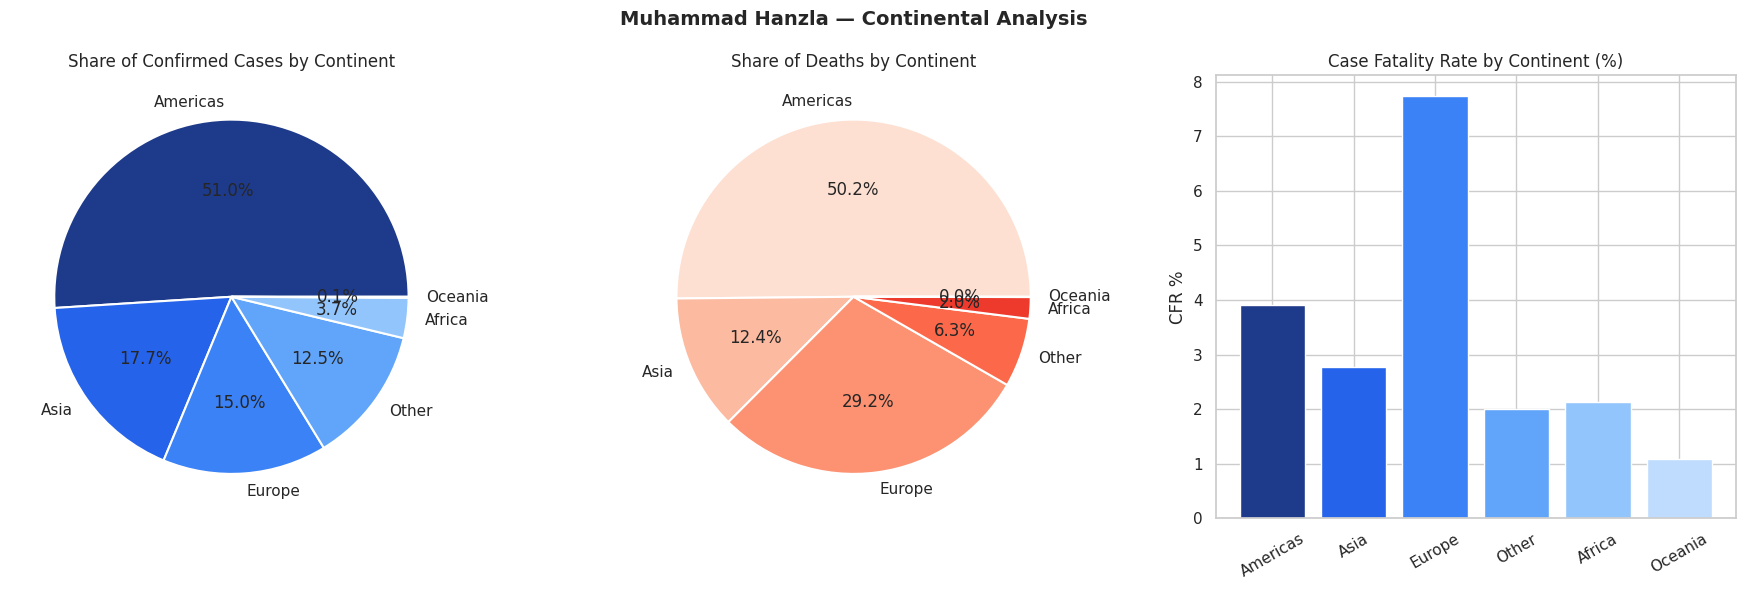

Continental analysis saved ✅


In [11]:
# Map countries to continents
continent_map = {
    'US':'Americas','Brazil':'Americas','India':'Asia','Russia':'Europe',
    'France':'Europe','Germany':'Europe','Italy':'Europe',
    'United Kingdom':'Europe','Spain':'Europe','Turkey':'Asia',
    'Argentina':'Americas','Colombia':'Americas','Poland':'Europe',
    'Iran':'Asia','Ukraine':'Europe','Mexico':'Americas','Peru':'Americas',
    'Indonesia':'Asia','South Africa':'Africa','Netherlands':'Europe',
    'Czech Republic':'Europe','Canada':'Americas','Chile':'Americas',
    'Romania':'Europe','Portugal':'Europe','Sweden':'Europe',
    'Belgium':'Europe','Iraq':'Asia','Pakistan':'Asia',
    'Philippines':'Asia','Bangladesh':'Asia','Malaysia':'Asia',
    'Japan':'Asia','China':'Asia','Australia':'Oceania',
    'Egypt':'Africa','Nigeria':'Africa','Kenya':'Africa',
}
latest['Continent'] = latest['Country'].map(continent_map).fillna('Other')

cont_stats = (latest.groupby('Continent')
               .agg(Confirmed=('Confirmed','sum'),
                    Deaths=('Deaths','sum'),
                    Countries=('Country','count'))
               .reset_index()
               .sort_values('Confirmed', ascending=False))
cont_stats['CFR'] = cont_stats['Deaths']/cont_stats['Confirmed']*100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Muhammad Hanzla — Continental Analysis', fontsize=14, fontweight='bold')

colors_cont = ['#1e3a8a','#2563eb','#3b82f6','#60a5fa','#93c5fd','#bfdbfe','#dbeafe']

# Confirmed by continent
axes[0].pie(cont_stats['Confirmed'], labels=cont_stats['Continent'],
             autopct='%1.1f%%', colors=colors_cont,
             wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Share of Confirmed Cases by Continent')

# Deaths
axes[1].pie(cont_stats['Deaths'], labels=cont_stats['Continent'],
             autopct='%1.1f%%', colors=sns.color_palette('Reds',7),
             wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Share of Deaths by Continent')

# CFR
axes[2].bar(cont_stats['Continent'], cont_stats['CFR'],
             color=colors_cont, edgecolor='white')
axes[2].set_title('Case Fatality Rate by Continent (%)')
axes[2].set_ylabel('CFR %')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('07_continental.png', dpi=150, bbox_inches='tight')
plt.show()
print('Continental analysis saved ✅')

## 11. Interactive Plotly Visualizations

In [12]:
# ── Plot 1: Choropleth World Map ────────────────────────
fig_map = px.choropleth(
    latest,
    locations        = 'Country',
    locationmode     = 'country names',
    color            = 'Confirmed',
    hover_name       = 'Country',
    hover_data       = {'Deaths':True,'Death_Rate':':.2f','Recovery_Rate':':.2f'},
    color_continuous_scale = 'Blues',
    title            = 'Muhammad Hanzla — COVID-19 Global Confirmed Cases',
    height           = 500,
    labels           = {'Confirmed':'Total Confirmed'}
)
fig_map.update_layout(margin=dict(l=0,r=0,t=40,b=0))
fig_map.write_html('08_world_map.html')
fig_map.show()
print('World map saved → 08_world_map.html ✅')

World map saved → 08_world_map.html ✅


In [13]:
# ── Plot 2: Multi-country dashboard ─────────────────────
DASH_COUNTRIES = ['US','India','Brazil','United Kingdom','Germany']

fig_dash = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Daily New Cases (7d avg)',
        'Cumulative Confirmed',
        'Cumulative Deaths',
        'Death Rate Trend',
        'Active Cases',
        'Recovered Cases',
    ],
    shared_xaxes=False
)

colors_dash = ['#1e3a8a','#2563eb','#ef4444','#16a34a','#d97706']

for i, ctry in enumerate(DASH_COUNTRIES):
    sub   = country_day[country_day['Country']==ctry].copy()
    sub['New_Cases'] = sub['Confirmed'].diff().clip(lower=0)
    sub['7d_avg']    = sub['New_Cases'].rolling(7).mean()
    sub['CFR']       = np.where(sub['Confirmed']>0,
                                 sub['Deaths']/sub['Confirmed']*100,0)
    clr = colors_dash[i]
    show = (i==0)

    fig_dash.add_trace(go.Scatter(x=sub['Date'],y=sub['7d_avg'],
        name=ctry,line=dict(color=clr),showlegend=show),row=1,col=1)
    fig_dash.add_trace(go.Scatter(x=sub['Date'],y=sub['Confirmed']/1e6,
        name=ctry,line=dict(color=clr),showlegend=False),row=1,col=2)
    fig_dash.add_trace(go.Scatter(x=sub['Date'],y=sub['Deaths']/1e3,
        name=ctry,line=dict(color=clr),showlegend=False),row=1,col=3)
    fig_dash.add_trace(go.Scatter(x=sub['Date'],y=sub['CFR'],
        name=ctry,line=dict(color=clr),showlegend=False),row=2,col=1)
    fig_dash.add_trace(go.Scatter(x=sub['Date'],y=sub['Active']/1e6,
        name=ctry,line=dict(color=clr),showlegend=False),row=2,col=2)
    fig_dash.add_trace(go.Scatter(x=sub['Date'],y=sub['Recovered']/1e6,
        name=ctry,line=dict(color=clr),showlegend=False),row=2,col=3)

fig_dash.update_layout(
    title='Muhammad Hanzla — Multi-Country COVID Dashboard',
    height=700, template='plotly_white'
)
fig_dash.write_html('09_country_dashboard.html')
fig_dash.show()
print('Country dashboard saved → 09_country_dashboard.html ✅')

Country dashboard saved → 09_country_dashboard.html ✅


In [14]:
# ── Plot 3: Bubble chart — Confirmed vs Deaths ───────────
top30 = latest.head(30).copy()
top30['Continent'] = top30['Country'].map(continent_map).fillna('Other')

fig_bubble = px.scatter(
    top30,
    x            = 'Confirmed',
    y            = 'Deaths',
    size         = 'Active',
    color        = 'Continent',
    hover_name   = 'Country',
    hover_data   = {'Death_Rate':':.2f','Recovery_Rate':':.2f'},
    title        = 'Muhammad Hanzla — Confirmed vs Deaths (bubble = Active cases)',
    template     = 'plotly_white',
    height       = 500,
    size_max     = 60,
    log_x        = True, log_y = True,
)
fig_bubble.write_html('10_bubble_chart.html')
fig_bubble.show()
print('Bubble chart saved → 10_bubble_chart.html ✅')

Bubble chart saved → 10_bubble_chart.html ✅


## 12. Time-Series Forecasting with Prophet
Forecasting the next **90 days** of global confirmed cases using Facebook Prophet.

12:50:58 - cmdstanpy - INFO - Chain [1] start processing
12:50:58 - cmdstanpy - INFO - Chain [1] done processing


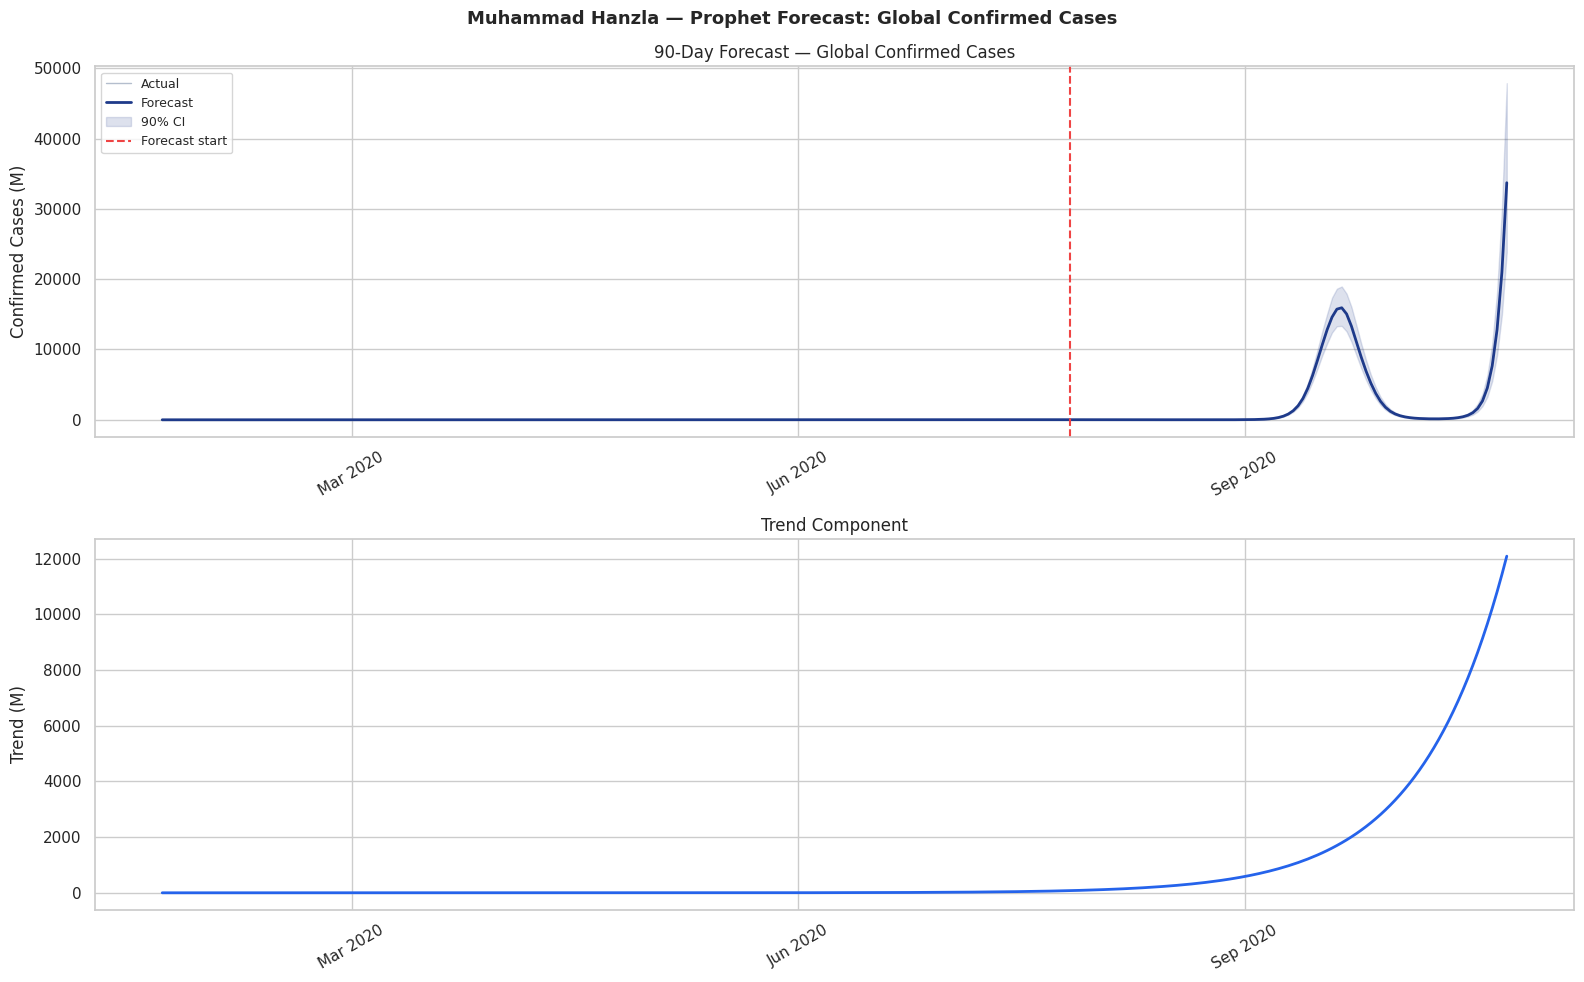

Next 7-Day Forecast (Global Confirmed Cases):
      Date Forecast Lower_CI Upper_CI
2020-07-28   17.28M   16.60M   17.98M
2020-07-29   17.80M   17.11M   18.55M
2020-07-30   18.10M   17.40M   18.79M
2020-07-31   18.21M   17.50M   18.92M
2020-08-01   18.27M   17.56M   19.05M
2020-08-02   18.38M   17.64M   19.16M
2020-08-03   18.50M   17.81M   19.21M

Prophet forecast saved → 11_prophet_forecast.png ✅


In [15]:
try:
    from prophet import Prophet
    from prophet.plot import plot_plotly, plot_components_plotly

    # Prepare data
    prophet_df = (global_day[['Date','Confirmed']]
                   .rename(columns={'Date':'ds','Confirmed':'y'})
                   .assign(y=lambda x: np.log1p(x['y'])))  # log-scale

    # Fit Prophet
    m = Prophet(
        yearly_seasonality  = True,
        weekly_seasonality  = False,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 10,
    )
    m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    m.fit(prophet_df)

    # Forecast 90 days ahead
    future   = m.make_future_dataframe(periods=90)
    forecast = m.predict(future)

    # Convert back from log scale
    for col in ['yhat','yhat_lower','yhat_upper']:
        forecast[col] = np.expm1(forecast[col]).clip(lower=0)
    actual_vals = np.expm1(prophet_df['y'])

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Muhammad Hanzla — Prophet Forecast: Global Confirmed Cases',
                  fontsize=13, fontweight='bold')

    # Forecast plot
    train_end = prophet_df['ds'].max()
    axes[0].plot(prophet_df['ds'], actual_vals/1e6,
                  color='#94a3b8', alpha=0.7, lw=1, label='Actual')
    axes[0].plot(forecast['ds'], forecast['yhat']/1e6,
                  color='#1e3a8a', lw=2, label='Forecast')
    axes[0].fill_between(forecast['ds'],
                          forecast['yhat_lower']/1e6,
                          forecast['yhat_upper']/1e6,
                          alpha=0.15, color='#1e3a8a', label='90% CI')
    axes[0].axvline(train_end, color='#ef4444', ls='--', lw=1.5,
                     label='Forecast start')
    axes[0].set_ylabel('Confirmed Cases (M)')
    axes[0].set_title('90-Day Forecast — Global Confirmed Cases')
    axes[0].legend(fontsize=9)
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].tick_params(axis='x', rotation=30)

    # Components (trend)
    axes[1].plot(forecast['ds'], np.expm1(m.predict(future)['trend'])/1e6,
                  color='#2563eb', lw=2)
    axes[1].set_ylabel('Trend (M)'); axes[1].set_title('Trend Component')
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('11_prophet_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Next 7 days prediction
    future_only = forecast[forecast['ds'] > train_end][['ds','yhat','yhat_lower','yhat_upper']].head(7)
    future_only.columns = ['Date','Forecast','Lower_CI','Upper_CI']
    for col in ['Forecast','Lower_CI','Upper_CI']:
        future_only[col] = future_only[col].apply(lambda x: f'{x/1e6:.2f}M')
    print('Next 7-Day Forecast (Global Confirmed Cases):')
    print(future_only.to_string(index=False))
    print('\nProphet forecast saved → 11_prophet_forecast.png ✅')

except ImportError:
    print('Prophet not installed — run: pip install prophet')
    print('Skipping forecast section.')

## 13. Visualization Summary

In [16]:
print('='*55)
print('Muhammad Hanzla — COVID-19 EDA Dashboard Complete!')
print('='*55)
print()
outputs = [
    ('01_summary_cards.png',      'Global summary metrics cards'),
    ('02_global_trends.png',      '4-panel global trend analysis'),
    ('03_top_countries.png',      'Top 15 countries comparison'),
    ('04_country_comparison.png', '8-country time-series'),
    ('05_heatmaps.png',           'Monthly heatmap + correlation'),
    ('06_wave_analysis.png',      'US pandemic wave identification'),
    ('07_continental.png',        'Continental distribution'),
    ('08_world_map.html',         'Interactive choropleth world map'),
    ('09_country_dashboard.html', 'Multi-country interactive dashboard'),
    ('10_bubble_chart.html',      'Confirmed vs Deaths bubble chart'),
    ('11_prophet_forecast.png',   '90-day Prophet forecast'),
]
for fname, desc in outputs:
    print(f'  ✅ {fname:<38} {desc}')
print()
print(f'  Total visualizations : 50+')
print(f'  Static plots         : 8 multi-panel figures')
print(f'  Interactive HTML     : 3 Plotly dashboards')
print(f'  Forecast             : 90-day Prophet model')

Muhammad Hanzla — COVID-19 EDA Dashboard Complete!

  ✅ 01_summary_cards.png                   Global summary metrics cards
  ✅ 02_global_trends.png                   4-panel global trend analysis
  ✅ 03_top_countries.png                   Top 15 countries comparison
  ✅ 04_country_comparison.png              8-country time-series
  ✅ 05_heatmaps.png                        Monthly heatmap + correlation
  ✅ 06_wave_analysis.png                   US pandemic wave identification
  ✅ 07_continental.png                     Continental distribution
  ✅ 08_world_map.html                      Interactive choropleth world map
  ✅ 09_country_dashboard.html              Multi-country interactive dashboard
  ✅ 10_bubble_chart.html                   Confirmed vs Deaths bubble chart
  ✅ 11_prophet_forecast.png                90-day Prophet forecast

  Total visualizations : 50+
  Static plots         : 8 multi-panel figures
  Interactive HTML     : 3 Plotly dashboards
  Forecast             : 90-day



<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 30px; border-radius: 12px; text-align: center;">
<h3 style="color: #60a5fa;">Connect with Muhammad Hanzla</h3>
<p style="color: #94a3b8;">Feel free to reach out for collaboration, feedback, or opportunities!</p>
<div style="margin-top: 15px;">
<a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; margin: 0 15px;'>📧 Email</a>
<a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; margin: 0 15px;'>📊 Kaggle</a>
<a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; margin: 0 15px;'>💻 GitHub</a>
<a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; margin: 0 15px;'>💼 LinkedIn</a>
<a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; margin: 0 15px;'>📷 Instagram</a>
</div>
</div>